In [1]:
## Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from collections import Counter

PROCESSED = Path("../data/processed")
RAW = Path("../data/raw")

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.0f}".format)

## Load Data

In [2]:
## Load data
daily_sales   = pd.read_csv(PROCESSED / "daily_sales.csv", parse_dates=["date"])
product_sales = pd.read_csv(PROCESSED / "product_sales.csv")
details       = pd.read_csv(RAW / "transaction_details.csv")
products      = pd.read_csv(RAW / "products.csv")

daily_sales["day_of_week"] = daily_sales["date"].dt.day_name()
daily_sales["week"] = daily_sales["date"].dt.isocalendar().week

## Hari Penjualan Tertinggi

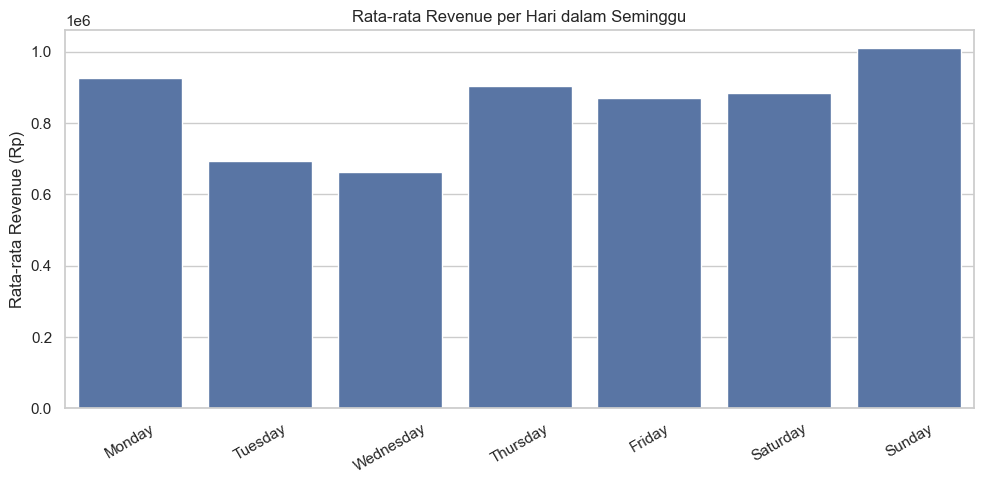

             avg_revenue  avg_trx
day_of_week                      
Monday           924,941        6
Tuesday          694,676        6
Wednesday        662,353        6
Thursday         904,353        6
Friday           871,306        6
Saturday         882,882       10
Sunday         1,009,265       11


In [3]:
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_dow = (
    daily_sales.groupby("day_of_week")
    .agg(avg_revenue=("total_revenue", "mean"), avg_trx=("total_transaksi", "mean"))
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=by_dow.reset_index(), x="day_of_week", y="avg_revenue", ax=ax)
ax.set_title("Rata-rata Revenue per Hari dalam Seminggu")
ax.set_xlabel("")
ax.set_ylabel("Rata-rata Revenue (Rp)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(by_dow)

## Produk Ynag sering Dibeli Bersamaan

In [4]:
# Ambil nama produk per transaksi
details_named = details.merge(products[["id", "name"]], left_on="product_id", right_on="id")
basket = details_named.groupby("transaction_id")["name"].apply(list)

pair_counts = Counter()
for items in basket:
    unique_items = sorted(set(items))
    if len(unique_items) < 2:
        continue
    for pair in combinations(unique_items, 2):
        pair_counts[pair] += 1

co_occurrence = (
    pd.DataFrame(
        [(a, b, count) for (a, b), count in pair_counts.items()],
        columns=["produk_a", "produk_b", "jumlah_transaksi_bersama"]
    )
    .sort_values("jumlah_transaksi_bersama", ascending=False)
    .reset_index(drop=True)
)

print(co_occurrence.head(10))

     produk_a        produk_b  jumlah_transaksi_bersama
0  Aqua 600ml  Kopi Kapal Api                        49
1     Chitato  Kopi Kapal Api                        44
2     Chitato      Taro Snack                        43
3   Beras 5kg  Indomie Goreng                        41
4     Chitato  Indomie Goreng                        40
5  Aqua 600ml      Taro Snack                        39
6  Aqua 600ml  Indomie Goreng                        39
7  Aqua 600ml       Beras 5kg                        38
8  Aqua 600ml         Chitato                        37
9     Chitato       Telur 1kg                        37


## Tren Revenue

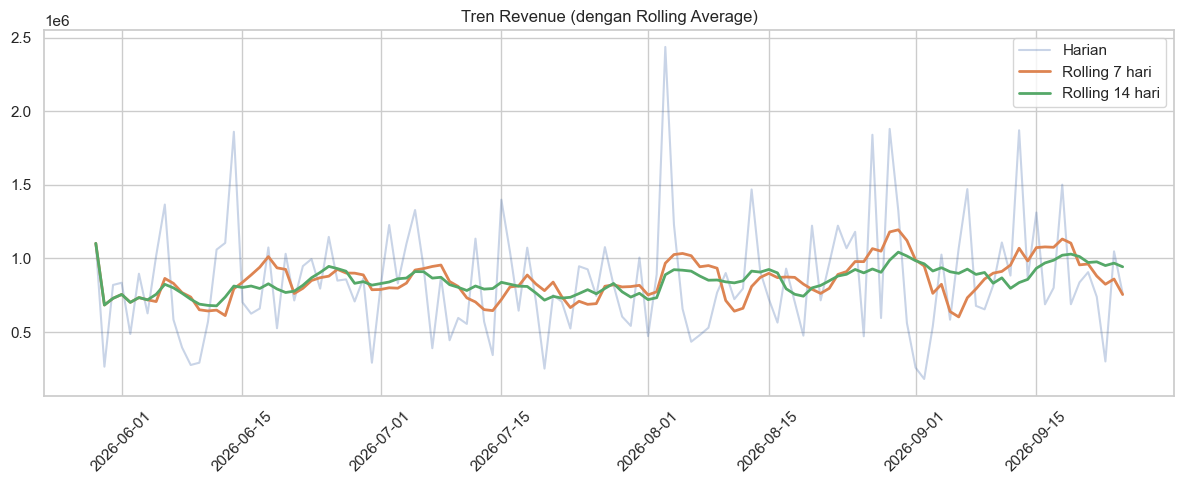

Rata-rata revenue 14 hari pertama : Rp681,179
Rata-rata revenue 14 hari terakhir: Rp943,357
Pertumbuhan: +38.5%


In [5]:
## 3. Tren revenue — naik atau turun?
daily_sales = daily_sales.sort_values("date")
daily_sales["revenue_ma7"] = daily_sales["total_revenue"].rolling(7, min_periods=1).mean()
daily_sales["revenue_ma14"] = daily_sales["total_revenue"].rolling(14, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_sales["date"], daily_sales["total_revenue"], alpha=0.3, label="Harian")
ax.plot(daily_sales["date"], daily_sales["revenue_ma7"], linewidth=2, label="Rolling 7 hari")
ax.plot(daily_sales["date"], daily_sales["revenue_ma14"], linewidth=2, label="Rolling 14 hari")
ax.set_title("Tren Revenue (dengan Rolling Average)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Growth rate kasar: bandingkan rata-rata 14 hari pertama vs 14 hari terakhir
early = daily_sales["total_revenue"].iloc[:14].mean()
late = daily_sales["total_revenue"].iloc[-14:].mean()
growth_pct = (late - early) / early * 100
print(f"Rata-rata revenue 14 hari pertama : Rp{early:,.0f}")
print(f"Rata-rata revenue 14 hari terakhir: Rp{late:,.0f}")
print(f"Pertumbuhan: {growth_pct:+.1f}%")

## Revenue Tinggi MArgin Rendah

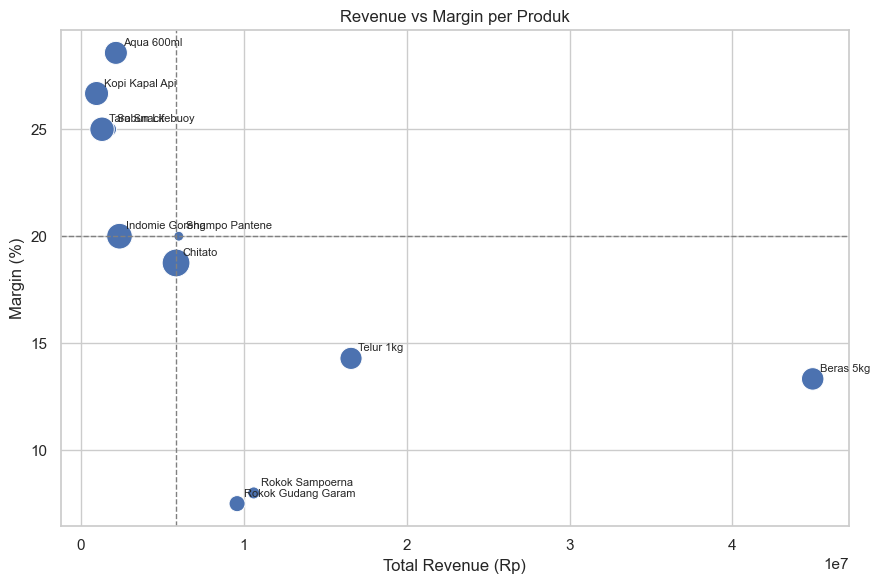

Produk revenue tinggi tapi margin di bawah median:
                 name  total_revenue  margin_pct
0           Beras 5kg     44,925,000          13
1           Telur 1kg     16,576,000          14
2     Rokok Sampoerna     10,600,000           8
3  Rokok Gudang Garam      9,580,000           8


In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=product_sales, x="total_revenue", y="margin_pct",
    size="total_qty", sizes=(50, 400), legend=False, ax=ax
)
for _, row in product_sales.iterrows():
    ax.annotate(row["name"], (row["total_revenue"], row["margin_pct"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.axhline(product_sales["margin_pct"].median(), color="gray", linestyle="--", linewidth=1)
ax.axvline(product_sales["total_revenue"].median(), color="gray", linestyle="--", linewidth=1)
ax.set_title("Revenue vs Margin per Produk")
ax.set_xlabel("Total Revenue (Rp)")
ax.set_ylabel("Margin (%)")
plt.tight_layout()
plt.show()

# Kuadran revenue tinggi, margin rendah — kandidat evaluasi harga/supplier
flagged = product_sales[
    (product_sales["total_revenue"] > product_sales["total_revenue"].median()) &
    (product_sales["margin_pct"] < product_sales["margin_pct"].median())
]
print("Produk revenue tinggi tapi margin di bawah median:")
print(flagged[["name", "total_revenue", "margin_pct"]])